In [ ]:
# @title Setup — Run this first
import os

if not os.path.exists('/content/MS_spectra_encoding'):
    !git clone https://github.com/Alexander-Sol/MS_spectra_encoding.git /content/MS_spectra_encoding

%cd /content/MS_spectra_encoding

# Install packages not pre-installed on Colab
!pip install -q pyteomics==4.6.1 spectrum-utils==0.4.2 rapidhash==0.1.0 mmh3

# TODO: download data file from Google Drive once hosted
# !gdown <FILE_ID> -O Data/04-17-23_CA_Tryp_HCD_10min-calib.mzML

## Goals:

In this notebook, we'll be exploring the following three core concepts:

1. Why we need to modify our idea of positional encoding to encode DIA data
2. How to build an "augmented spectrum" data structure that captures contextual information from neighboring MS1 and MS2 scans
3. How to encode the resulting 4-tuple peaks using sinusoidal positional encoding on real DIA data

In [ ]:
# @title Run this cell to import all necessary packages

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pyteomics import mzml
from util import *

## 4. Cascadia: Positional Embedding of Augmented Spectra

### 4.1 The Problem: What if one spectrum isn't enough?

In the previous notebook, we saw how Casanovo predicts peptide sequences over DDA data, whereas Cascadia predicts peptide sequences over **DIA** data. So what happens when:
- Your peptide's signal is spread across multiple MS2 cycles (like in DIA)?
- or the MS1 isotope pattern holds crucial information about charge state and mass?
- or neighboring spectra contain corroborating evidence that could improve predictions?

Our motivation here is to leverage all contextual information available to make a better prediction. With this in mind, we can better understand the reasoning behind the "Augmented Spectra" concept introduced in Cascadia.

<details>
<summary><strong>Data-Dependent Acquisition (DDA) vs. Data-Independent Acquisition (DIA)</strong></summary>

<img src='Images/DDA vs. DIA.png' width=500>

**DDA**: Each fragmentation spectrum corresponds to a single peptide.

At every MS1 scan, the instrument selects the top k most intense precursor ions. Only these precursors are isolated, fragmented, and recorded as MS2 spectra. This produces clean MS2 spectra, each representing one peptide, but at the cost of completeness — not all precursors are selected.

**DIA**: A single peptide is reconstructed from multiple time-adjacent spectra collected across wide, overlapping m/z windows.

Instead of selecting specific precursors, DIA fragments every ion within a set of predefined m/z windows. These windows often overlap to avoid losing peptides at boundaries. A single peptide typically contributes fragments to many consecutive MS2 spectra.

This produces more complex MS2 spectra, but the data is more complete because _all_ precursors are fragmented. For a visual of what I mean here, see the first few seconds of the video below.

---

</details>

### Constructing an Augmented Spectrum

The following animation walks through the three step process for building an augmented spectrum from MS1 and MS2 data:

**(1) Select a central MS2 scan**

**(2) Include neighboring MS2 scans within a chosen width, and**

**(3) Identify the corresponding MS1 scans in order to build the "augmented spectrum"**

# TODO improve and add back in `AugmentedManim`

### 4.2 Building an Augmented Spectrum Data Structure

Here are the elements of an augmented spectrum:

| Field | Description |
|-------|-------------|
| m/z | The mass-to-charge ratio of the peak |
| Intensity | Peak intensity, normalized to [0, 1] |
| Width | Relative position: `0` = central scan, `+1` = one scan forward, `-1` = one scan backward |
| Level | `2` = MS2 (fragment ions), `1` = MS1 (precursor/isotope peaks) |

A full augmented spectrum is a collection of peaks represented as 4-tuples: **(m/z, intensity, width, level)**.

---

#### Numeric Example of an Augmented Spectrum

In our video, we used width = 2, meaning we selected 2 MS2 scans on each side of the central scan. The example below from [Cascadia's documentation](https://cascadia.readthedocs.io/en/latest/file_formats.html) uses width = 1 (1 scan on each side), which makes it easier to trace through.



Metadata:
```md
TITLE=1
PEPMASS=402.5
CHARGE=1
SCAN=1
RT=0.31070598402
SEQ=PEPTIDEK
```

|m/z                    | intensity                |width | level|
|-----------------------|--------------------------|------|------|
|185.07986450195312      | 0.666241404428991       | 0     | 2
|367.8453063964844       | 0.4087404090593467      | 0     | 2
|400.98358154296875      | 0.8838386047632094      | 0     | 2
|401.1849060058594       | 0.4504917813994659      | 0     | 2
|401.2586669921875       | 0.42375381912879023     | 0     | 2
|401.9834289550781       | 0.6479885582525154      | 0     | 2
|418.99261474609375      | 0.6245163448036832      | 0     | 2
|606.7568359378328       | 0.41198908195979644     | 0     | 2
|606.756835937573        | 0.41198908195979644     | 0     | 2
|843.2614135742188       | 0.41591027114618606     | 0     | 2
|946.1708374023438       | 0.430206516710194       | 0     | 2
|185.07986450195312      | 0.666241404428991       | 1     | 2
|367.8453063964844       | 0.4087404090593467      | 1     | 2
|400.98358154296875      | 0.8838386047632094      | 1     | 2
|401.1849060058594       | 0.4504917813994659      | 1     | 2
|401.2586669921875       | 0.42375381912879023     | 1     | 2
|401.9834289550781       | 0.6479885582525154      | 1     | 2
|418.99261474609375      | 0.6245163448036832      | 1     | 2
|185.07986450195312      | 0.666241404428991       | -1    | 2
|367.8453063964844       | 0.4087404090593467      | -1    | 2
|400.98358154296875      | 0.8838386047632094      | -1    | 2
|401.1849060058594       | 0.4504917813994659      | -1    | 2
|401.2586669921875       | 0.42375381912879023     | -1    | 2
|401.9834289550781       | 0.6479885582525154      | -1    | 2
|418.99261474609375      | 0.6245163448036832      | -1    | 2
|606.7568359375737       | 0.41198908195979644     | -1    | 2
|843.2614135742188       | 0.41591027114618606     | -1    | 2
|946.1708374023438       | 0.430206516710194       | -1    | 2
|400.1812744140625       | 0.2918983249625358      | 0     | 1
|400.3501892089844       | 0.3196363715025925      | 0     | 1
|401.2091979980469       | 0.34867104752184375     | 0     | 1
|403.2320556640625       | 0.30672175589489503     | 0     | 1
|402.2713624687576       | 0.2951177103313615      | -1    | 1
|403.17193603515625      | 0.362321942870444       | -1    | 1


<br/>

> Note that all of the data here is exploded into peaks, so each row corresponds to one peak from a given MS2 (and its corresponding MS1) scan.

**The table above is just one augmented spectrum**, not several. It represents a single event. We've chosen a single central MS2 scan (at width = 0) plus its temporal neighbors.

Here's how to read the groups:

| What you see | What it means |
|---|---|
| Rows with `width=0, level=2` | Fragment peaks from the **central** MS2 scan|
| Rows with `width=+1, level=2` | Fragment peaks from the **next** occurrence of the same isolation window|
| Rows with `width=-1, level=2` | Fragment peaks from the **previous** occurrence|
| Rows with `level=1` | Precursor/isotope peaks from the **MS1** scan of that cycle |

Another corollary we can infer is the fact that the same m/z value shows up multiple times in different widths. This implies that the same fragment ion was detected across all 3 DIA cycles (width = -1,0, and 1), which is exactly the kind of contextual evidence we can gain from DIA that Cascadia is designed to exploit. It shows our model that this peak belongs to a real peptide, and isn't just noise. 

That being said, let's continually keep in mind our motivation. A single MS2 spectrum in DIA is inherently ambiguous - it contains fragments from **all** precursors present in a given isolation window. By combining information across time (neighboring scans) and across MS levels (MS1 and MS2), the augmented spectrum lets us encode all of this context.

### 4.3 Building the Augmented Spectrum from Real DIA Data

Each DIA cycle contains 1 MS1 scan followed by 38 MS2 scans, each covering a different 5 Da isolation window (±2.5 Da).

To build an augmented spectrum with width = 1, we need three consecutive appearances of the same isolation window:

| Width | Which occurrence | Role |
|-------|-----------------|------|
| -1 | occurrence N-1 | previous scan |
| 0 | occurrence N | central scan |
| +1 | occurrence N+1 | next scan |

We'll use the isolation window centered at **m/z = 818.1** (window [815.6, 820.6] Da), which has dense MS1 and MS2 peaks.

In [ ]:
#@title Run this cell to read in the data

DIA_FILE = 'DIA/E24484_Mag_1_4_50_3.mzML'

with mzml.read(DIA_FILE) as f:
    scans = list(f)

ms1_indices = [i for i, s in enumerate(scans) if s['ms level'] == 1]
cycle_len = ms1_indices[1] - ms1_indices[0]

print(f'Total scans: {len(scans)}')
print(f'MS1 scans:   {len(ms1_indices)}')
print(f'Cycle length: {cycle_len} ({cycle_len - 1} MS2 + {1} MS1)')

Total scans: 767
MS1 scans:   20
Cycle length: 39 (38 MS2 + 1 MS1)


DIA data has a bit more complexity in terms of isolating a single MS2 scan, 

In [ ]:
# @title Run this cell to find MS2 scans matching the target isolation window and count MS1 peaks in the window

TARGET_IW = 818.1   # isolation window target m/z
IW_HALF   = 2.5     # window half-width

def find_ms2_in_cycle(cycle_num, target_isolation_window, scans, ms1_indices):
    """Return (index, scan) for the MS2 in cycle_num matching target_isolation_window."""
    ms1_idx      = ms1_indices[cycle_num] # index of the MS1 scan starting this cycle
    next_ms1_idx = ms1_indices[cycle_num + 1] # index of the next MS1 scan starting the next cycle
    for i in range(ms1_idx + 1, next_ms1_idx): # loop over MS2 scans in this cycle
        iw = scans[i]['precursorList']['precursor'][0]['isolationWindow'] # get isolation window info
        if abs(iw['isolation window target m/z'] - target_isolation_window) < 0.5:
            return i, scans[i]
    return None, None

def get_ms1_in_window(cycle_num, target_isolation_window, iw_half, scans, ms1_indices):
    """Return (mz, intensity) arrays for MS1 peaks inside the isolation window."""
    s   = scans[ms1_indices[cycle_num]]
    mz  = s.get('m/z array', np.array([]))
    int = s.get('intensity array', np.array([]))
    mask = (mz >= target_isolation_window - iw_half) & (mz <= target_isolation_window + iw_half)
    return mz[mask], int[mask]

# Cycles 1, 5, 9 all contain isolation window ~818.1
CYCLES = {-1: 1, 0: 5, 1: 9}   # map of {width : cycle_number}

for w, c in CYCLES.items():
    idx, scan = find_ms2_in_cycle(c, TARGET_IW, scans, ms1_indices)
    rt        = scan['scanList']['scan'][0]['scan start time']
    ms1_mz, _ = get_ms1_in_window(c, TARGET_IW, IW_HALF, scans, ms1_indices)
    print(f'width={w:+d}  cycle={c}  MS2_idx={idx}  rt={rt:.3f} min  '
          f'MS2_peaks={len(scan["m/z array"])}  MS1_in_window={len(ms1_mz)}')

width=-1  cycle=1  MS2_idx=69  rt=37.090 min  MS2_peaks=1931  MS1_in_window=49
width=+0  cycle=5  MS2_idx=225  rt=37.293 min  MS2_peaks=3402  MS1_in_window=64
width=+1  cycle=9  MS2_idx=381  rt=37.498 min  MS2_peaks=2475  MS1_in_window=92


In [4]:
def normalize(arr):
    mx = arr.max()
    return arr / mx if mx > 0 else arr

rows = []

for w, c in CYCLES.items():
    # MS2 peaks — take top 50 by intensity
    _, ms2 = find_ms2_in_cycle(c, TARGET_IW, scans, ms1_indices)
    mz2  = ms2.get('m/z array', np.array([]))
    int2 = normalize(ms2.get('intensity array', np.array([])))
    top  = np.argsort(int2)[::-1][:50]
    for i in top:
        rows.append({'m/z': round(float(mz2[i]), 4),
                     'intensity': round(float(int2[i]), 4),
                     'width': w, 'level': 2})

    # MS1 peaks within isolation window
    ms1_mz, ms1_int = get_ms1_in_window(c, TARGET_IW, IW_HALF, scans, ms1_indices)
    if len(ms1_int) > 0:
        ms1_int_norm = normalize(ms1_int)
        for mz_val, int_val in zip(ms1_mz, ms1_int_norm):
            rows.append({'m/z': round(float(mz_val), 4),
                         'intensity': round(float(int_val), 4),
                         'width': w, 'level': 1})

aug_df = pd.DataFrame(rows)
print(f'Augmented spectrum: {len(aug_df)} total peaks')
print()
print(aug_df.groupby(['width', 'level']).size()
          .reset_index(name='peaks')
          .to_string(index=False))
aug_df.head(10)

Augmented spectrum: 355 total peaks

 width  level  peaks
    -1      1     49
    -1      2     50
     0      1     64
     0      2     50
     1      1     92
     1      2     50


,m/z,intensity,width,level
0,819.4313,1.0000,-1,2
1,820.4454,0.5515,-1,2
2,817.4212,0.3787,-1,2
3,818.4322,0.2317,-1,2
4,777.3968,0.0812,-1,2
5,274.0935,0.0804,-1,2
6,596.3535,0.0766,-1,2
7,272.1728,0.0664,-1,2
8,298.6796,0.0648,-1,2
9,175.1195,0.0637,-1,2


### 4.4 Encoding Each 4-Tuple

We now have our augmented spectrum as a table of 4-tuples. The next step is to convert each tuple into a fixed-size vector the transformer can operate on.

Recall that in Casanovo, each peak was described by just 2 numbers: m/z and intensity. Cascadia extends this to 4 numbers by adding **width** and **level**.

The encoding strategy for each component:

| Component | Value range | Encoding method |
|-----------|------------|------------------|
| m/z | continuous, ~100–2000 Da | Sinusoidal PE (same as Casanovo) |
| width | integer, {-1, 0, +1} | Sinusoidal PE (same formula) |
| intensity | continuous, [0, 1] | Learned linear layer |
| level | binary, {1, 2} | Learned linear layer |

The two sinusoidal encodings (m/z and width) are concatenated into $v_{\text{mz+rt}}$. The two learned encodings (intensity and level) are each produced by a linear transformation $v = Wx + b$ and concatenated alongside. The full vector is then:

$$v_{\text{peak}} = [v_{\text{mz}} \;\|\; v_{\text{rt}} \;\|\; v_{\text{int}} \;\|\; v_{\text{level}}]$$

We'll focus here on the two concrete sinusoidal pieces — m/z and width — since those are fully determined by the data (no training needed).

In [5]:
def make_wavelength_list(dimensions, lambda_min=0.001, lambda_max=10000):
    """
    Generate wavelengths following the Casanovo formula:
    lambda_i = (lambda_min / 2pi) * (lambda_max / lambda_min)^(i / (d_sin - 1))
    """
    d_sin = dimensions // 2
    i = np.arange(d_sin)
    return (lambda_min / (2 * np.pi)) * (lambda_max / lambda_min) ** (i / (d_sin - 1))

def sinusoidal_encoding(value, dimensions=512, lambda_min=0.001, lambda_max=10000):
    """
    Encode a scalar value into a d_model-dimensional sinusoidal vector.
    First half: sine encoding. Second half: cosine encoding.
    """
    wavelengths = make_wavelength_list(dimensions, lambda_min, lambda_max)
    d_sin = dimensions // 2
    enc = np.empty(dimensions)
    enc[:d_sin] = np.sin(value / wavelengths)
    enc[d_sin:] = np.cos(value / wavelengths)
    return enc

#### Encoding a single peak

Let's trace through the encoding for the highest-intensity MS2 peak in our central scan (width = 0).

In [6]:
# Get the top peak from the central MS2 scan
_, central_scan = find_ms2_in_cycle(5, TARGET_IW, scans, ms1_indices)
mz2  = central_scan.get('m/z array')
int2 = central_scan.get('intensity array')

top_i     = np.argmax(int2)
top_mz    = float(mz2[top_i])
top_int   = float(int2[top_i]) / float(int2.max())
top_width = 0   # central scan
top_level = 2   # MS2

print(f'Peak: m/z={top_mz:.3f}, intensity={top_int:.4f}, width={top_width}, level={top_level}')
print()

enc_mz    = sinusoidal_encoding(top_mz)
enc_width = sinusoidal_encoding(top_width)

print(f'enc_mz    shape: {enc_mz.shape}')
print(f'enc_width shape: {enc_width.shape}')
print()
print(f'enc_mz    (dims 0-5):   {enc_mz[:6].round(4)}')
print(f'enc_width (dims 0-5):   {enc_width[:6].round(4)}')
print()
print('Note: width=0 encodes to sin(0/λ)=0 and cos(0/λ)=1 for all λ')
print('      This is the "origin" encoding — the central scan.')

Peak: m/z=706.890, intensity=1.0000, width=0, level=2

enc_mz    shape: (512,)
enc_width shape: (512,)

enc_mz    (dims 0-5):   [-0.9954  0.9133  0.0883  0.6885 -0.5099  0.2196]
enc_width (dims 0-5):   [0. 0. 0. 0. 0. 0.]

Note: width=0 encodes to sin(0/λ)=0 and cos(0/λ)=1 for all λ
      This is the "origin" encoding — the central scan.


#### Visualizing the Augmented Spectrum Encodings

Below we plot the m/z encoding for all peaks in the augmented spectrum. Each column is one peak, each row is one encoding dimension. The peaks are grouped by their width value (−1, 0, +1) and MS level.

The striped pattern within each width group is the same sinusoidal fingerprint we saw in Notebook 3 — what's new is that the **grouping by width** lets the transformer distinguish which scan each peak came from.

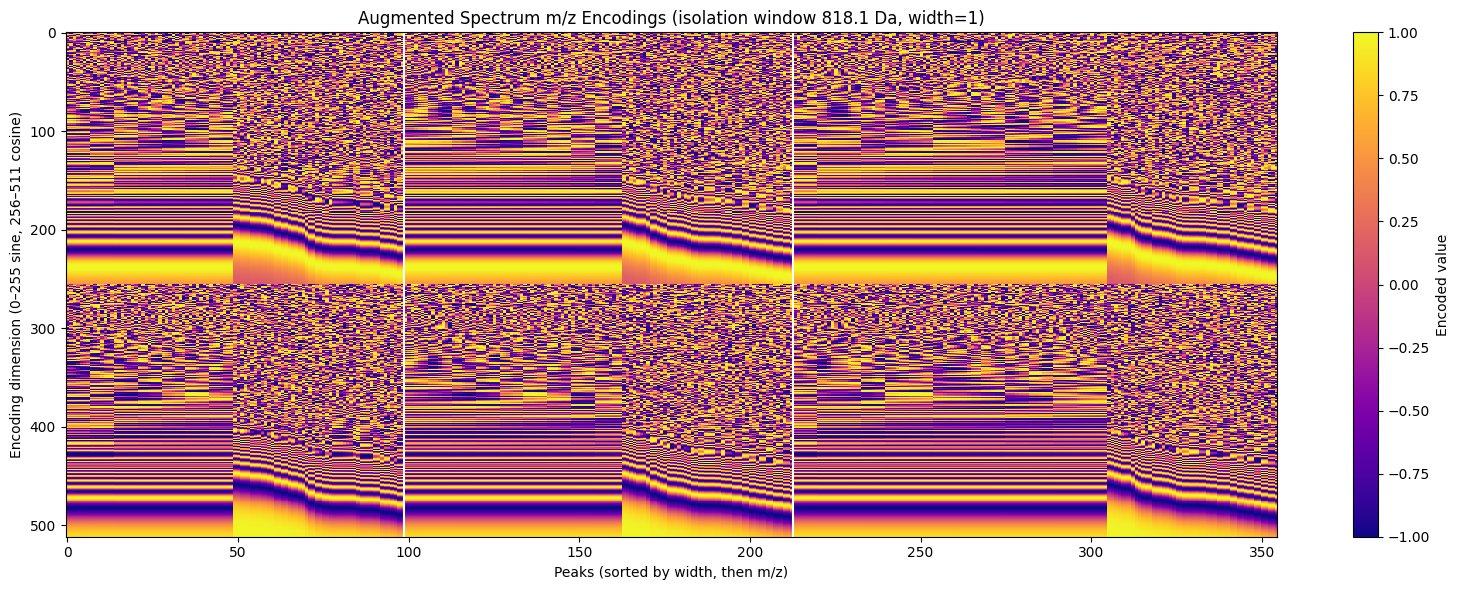

In [7]:
# Sort peaks: group by width, then by m/z within each group
aug_sorted = aug_df.sort_values(['width', 'level', 'm/z']).reset_index(drop=True)

# Encode m/z for each peak
mz_enc = np.vstack([sinusoidal_encoding(float(row['m/z'])) for _, row in aug_sorted.iterrows()])

# Plot
fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(mz_enc.T, aspect='auto', cmap='plasma', vmin=-1, vmax=1, interpolation='nearest')
plt.colorbar(im, ax=ax, label='Encoded value')

# Mark width-group boundaries with vertical lines
counts = aug_sorted.groupby('width').size().sort_index()
boundary = 0
for w, cnt in counts.items():
    if boundary > 0:
        ax.axvline(boundary - 0.5, color='white', linewidth=1.5)
    mid = boundary + cnt // 2
    ax.text(mid, -18, f'width={w:+d}', ha='center', va='top', color='white', fontsize=9)
    boundary += cnt

ax.set_xlabel('Peaks (sorted by width, then m/z)')
ax.set_ylabel('Encoding dimension (0–255 sine, 256–511 cosine)')
ax.set_title(f'Augmented Spectrum m/z Encodings (isolation window {TARGET_IW} Da, width=1)')
plt.tight_layout()
plt.show()